In [36]:
import torch
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
import numpy as np

import sys
sys.path.append('./FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic')
from flocat import flocatTrainer, flocat
import evaluation as ev

%load_ext autoreload
%autoreload 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


device(type='cuda')

# Images

In [72]:
def load_embeddings(path):
    return torch.load(path, map_location="cpu")

# embeder = "wide_resnet50_2"
embeder = "vit_base_patch16_224"

# level = "image_level"
# level = "vitpatch_level"
level = "diypatch_level"
sublevel = "_manual_p64"

inlier_topic = "screw"

data_train = load_embeddings(f"/home/2017025/ayouce01/FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic/data/embeddings/{level}/{embeder+sublevel}/{inlier_topic}/train.pt")
# data_train = load_embeddings(f"/home/2017025/ayouce01/FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic/data/embeddings/{level}/{embeder}/{inlier_topic}/train.pt")
X_train = data_train["embeddings"]          

data_test = load_embeddings(f"/home/2017025/ayouce01/FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic/data/embeddings/{level}/{embeder+sublevel}/{inlier_topic}/test.pt")
# data_test = load_embeddings(f"/home/2017025/ayouce01/FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic/data/embeddings/{level}/{embeder}/{inlier_topic}/test.pt")
X_test = data_test["embeddings"]
y_test = data_test["labels"]
print(X_train.shape)
print(X_test.shape)

torch.Size([320, 16, 768])
torch.Size([160, 16, 768])


/tmp/ipykernel_4086093/2311803383.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location="cpu")


In [73]:
#--------------------------------
# PATCH LEVEL
#--------------------------------


batch_size = 32
num_patches = X_train.shape[1]
attentions_train_mask = torch.ones((X_train.shape[0], num_patches), dtype=torch.long)
attentions_test_mask = torch.ones((X_test.shape[0], num_patches), dtype=torch.long)

flocat_config = {
    "latent_dim": X_train.shape[-1], "hidden_dim": 64, "depth": 2, "n_heads": 2,
    "freq_embed_size": 128, "lr": 1e-2, "weight_decay": 1e-4, "lambda_love": 1e-3,
    "epochs": 300, "lr_epochs": 120, "batch_size": batch_size,
    "coef_var": 1e-3, "target": "gaussian-neigh", "source": X_train,
    "attentions_mask": attentions_train_mask, "device": device,
}
flow_model = flocat(
    latent_dim=flocat_config["latent_dim"],
    hidden_dim=flocat_config["hidden_dim"],
    depth=flocat_config["depth"],
    n_heads=flocat_config["n_heads"],
).to(device)
flocatformer = flocatTrainer(flow_model, flocat_config)

t0 = time.time()
flocatformer.train(True)
t1 = time.time()
auc, fpr, ap = flocatformer.test(
    X_test, y_test, attentions_test_mask, type="norm-centroid", n_steps=10,
)
print(f"FLOCAT-GENAGN --> AUC: {auc:.4f} | FPR@95: {fpr:.4f} | AP: {ap:.4f}\n")


#--------------------------------
# IMAGE LEVEL
#--------------------------------


# batch_size = 32

# flocat_config = {
#     "latent_dim": X_train.shape[-1], "hidden_dim": 64, "depth": 2, "n_heads": 2,
#     "freq_embed_size": 128, "lr": 1e-3, "weight_decay": 1e-4, "lambda_love": 1e-3,
#     "epochs": 300, "lr_epochs": 120, "batch_size": batch_size,
#     "coef_var": 1e-3, "target": "gaussian-neigh", "source": X_train,
#     "attentions_mask": None, "device": device,
# }
# flow_model = flocat(
#     latent_dim=flocat_config["latent_dim"],
#     hidden_dim=flocat_config["hidden_dim"],
#     depth=flocat_config["depth"],
#     n_heads=flocat_config["n_heads"],
# ).to(device)
# flocatformer = flocatTrainer(flow_model, flocat_config)

# t0 = time.time()
# flocatformer.train(True)
# t1 = time.time()
# auc, fpr, ap = flocatformer.test(
#     X_test, y_test, type="norm-centroid", n_steps=10,
# )
# print(f"FLOCAT-GENAGN --> AUC: {auc:.4f} | FPR@95: {fpr:.4f} | AP: {ap:.4f}\n")


Epoch 1/300
Train Loss: 0.0799, LR: 0.000083
tensor(1., device='cuda:0', grad_fn=<ExpBackward0>)

Epoch 101/300
Train Loss: 0.0067, LR: 0.008347
tensor(1., device='cuda:0', grad_fn=<ExpBackward0>)

Epoch 201/300
Train Loss: 0.0039, LR: 0.005868
tensor(1., device='cuda:0', grad_fn=<ExpBackward0>)
AUC:        0.1441
Avg Precision: 0.5711
FPR@95:     1.0000
FLOCAT-GENAGN --> AUC: 0.1441 | FPR@95: 1.0000 | AP: 0.5711



In [ ]:
n_steps = 6
all_x_final, all_velocities, all_x_inter = flocatformer.euler_integrate(
    X_test.to(device),
    attentions_test_mask.to(device),
    n_steps, True
)

metrics_inter = {}
for i,x_temp in enumerate(all_x_inter):

    centroid_np = flocatformer.centroid.cpu().numpy() 
    scores = np.sum(
        (x_temp.cpu().numpy() - centroid_np) ** 2, axis=1
    )
    auc, fpr, ap = ev.evaluation(y_test, scores, False)
    metrics_inter[i] = (auc.round(4), fpr.round(4), ap.round(4))

# n_steps = 6
# attention_mask = torch.ones(X_test.shape[0], 1, device=X_test.device)
# all_x_final, all_velocities, all_x_inter = flocatformer.euler_integrate(
#     X_test.to(device),
#     attention_mask.to(device),
#     n_steps, True
# )

# metrics_inter = {}
# for i,x_temp in enumerate(all_x_inter):

#     centroid_np = flocatformer.centroid.cpu().numpy() 
#     scores = np.sum(
#         (x_temp.cpu().numpy() - centroid_np) ** 2, axis=1
#     )
#     auc, fpr, ap = ev.evaluation(y_test, scores, False)
#     metrics_inter[i] = (auc.round(4), fpr.round(4), ap.round(4))


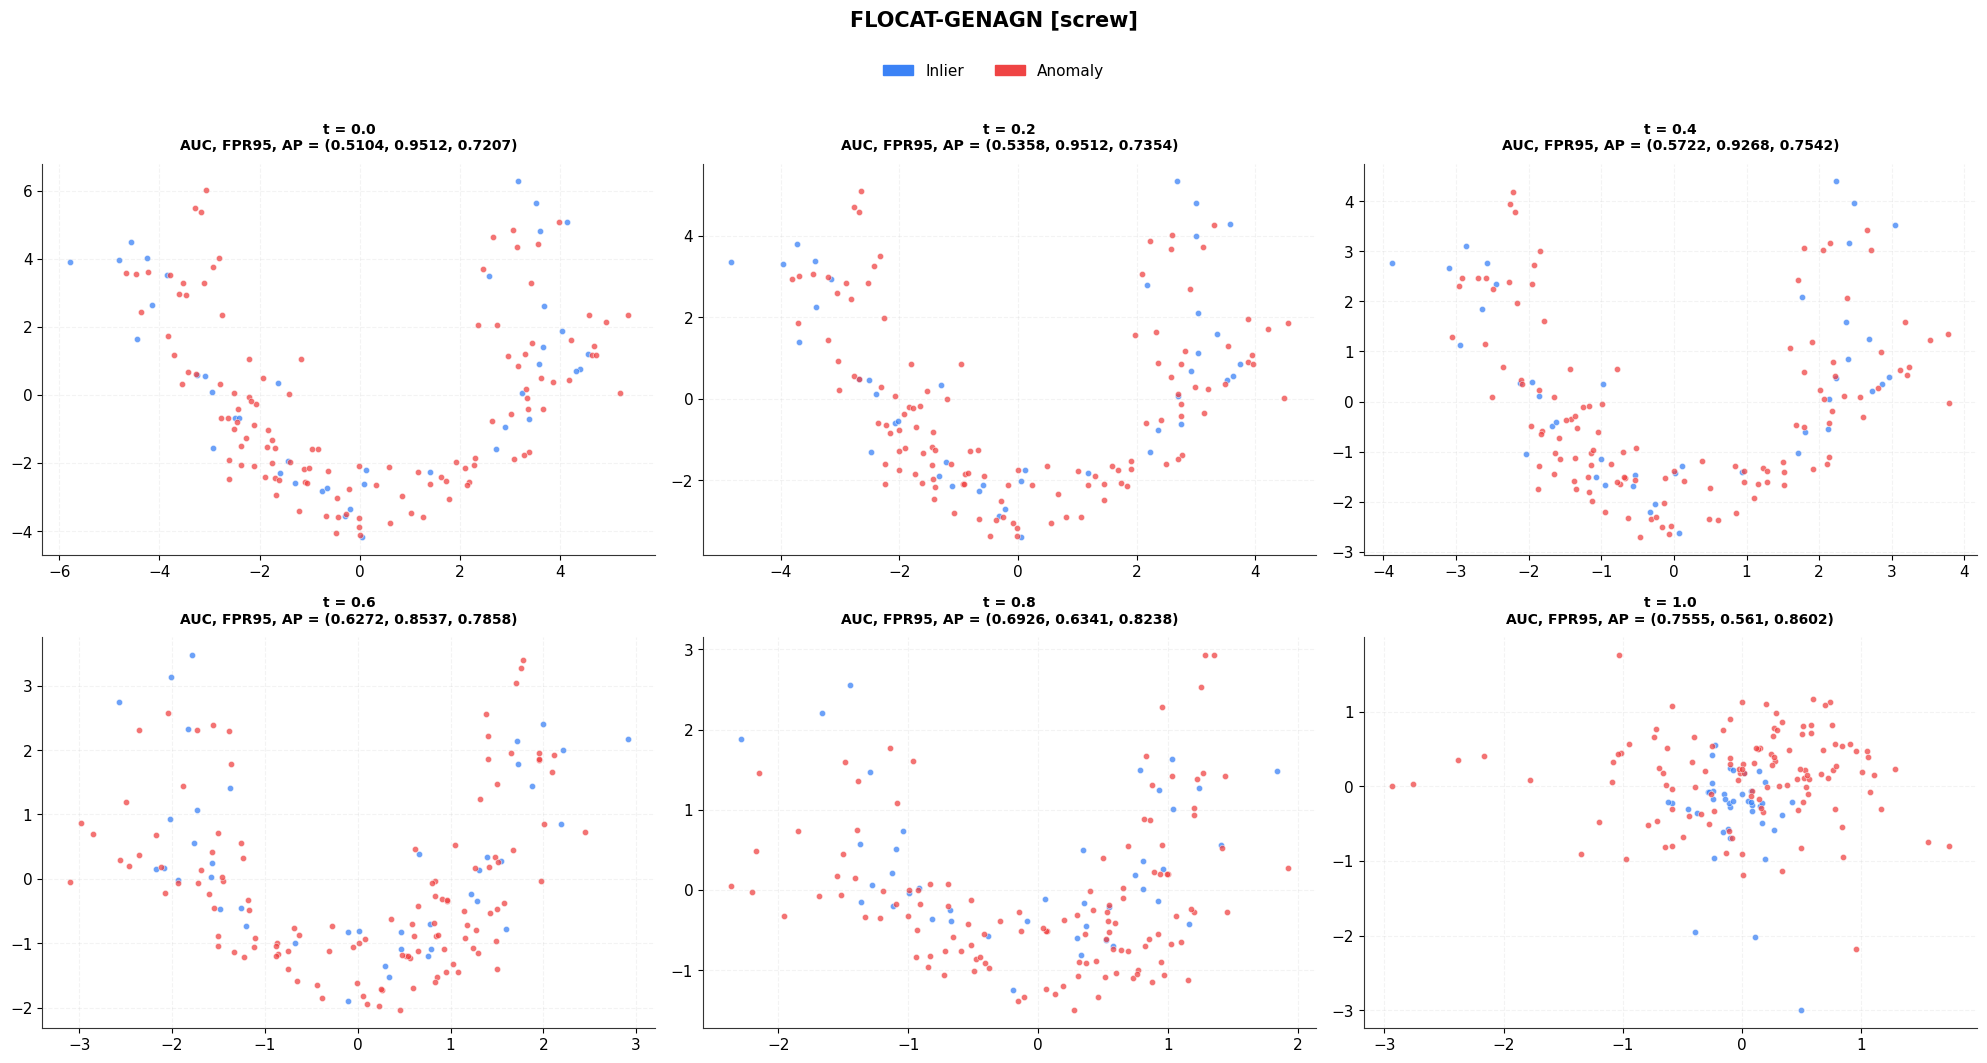

In [71]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
})

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.patch.set_facecolor('white')
axes = axes.flatten()
steps = torch.linspace(0, 1, n_steps)

color_map = {0: '#3B82F6', 1: '#EF4444'}  
label_map = {0: 'Inlier', 1: 'Anomaly'}
y_test_arr = np.array(y_test)

for i in range(6):
    X_i = all_x_inter[i].detach().cpu().numpy()

    pca = PCA(n_components=2)
    X_i_pca = pca.fit_transform(X_i)

    ax = axes[i]

    for cls, color in color_map.items():
        mask = y_test_arr == cls
        ax.scatter(
            X_i_pca[mask, 0],
            X_i_pca[mask, 1],
            c=color,
            label=label_map[cls],
            alpha=0.75,
            s=20,
            edgecolors='white',
            linewidths=0.4,
        )

    ax.set_title(
        f"t = {steps[i]:.1f}\n"
        f"AUC, FPR95, AP = {metrics_inter[i]}",
        fontsize=10,
        fontweight='bold',
        pad=10
    )

    ax.grid(alpha=0.15, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

handles = [mpatches.Patch(color=c, label=label_map[k]) for k, c in color_map.items()]
fig.legend(handles=handles, loc='upper center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.02), fontsize=11)

fig.suptitle(f"FLOCAT-GENAGN [{inlier_topic}]",
             fontsize=15, fontweight='bold', y=1.06)

plt.tight_layout(w_pad=1)
plt.show()

In [97]:
# !pip install open_clip_torch --break-system-packages

import open_clip

def build_clip_model(model_name="ViT-B-32", pretrained="openai", device="cpu"):
    model, _, preprocess = open_clip.create_model_and_transforms(
        model_name, pretrained=pretrained
    )
    model = model.to(device).eval()
    return model, preprocess

In [99]:
def extract_clip_embeddings(model, images):
    """Retourne un embedding global [B, D] par image (pas de grille spatiale)."""
    with torch.no_grad():
        embeddings = model.encode_image(images)  # [B, D]
    return embeddings.unsqueeze(1), (embeddings.shape[0], 1, 1)  # -> [B, 1, D] pour rester cohérent avec le format existant

def extract_clip_patch_embeddings(model, images):
    """Récupère les tokens patch du ViT de CLIP avant le pooling final."""
    with torch.no_grad():
        x = model.visual.conv1(images)  # patch embedding
        x = x.reshape(x.shape[0], x.shape[1], -1).permute(0, 2, 1)  # [B, N_patches, D]
        x = torch.cat([model.visual.class_embedding.expand(x.shape[0], 1, -1), x], dim=1)
        x = x + model.visual.positional_embedding
        x = model.visual.ln_pre(x)
        x = x.permute(1, 0, 2)
        x = model.visual.transformer(x)
        x = x.permute(1, 0, 2)
        patch_tokens = x[:, 1:, :]  # on retire le token [CLS]

    B, N, C = patch_tokens.shape
    H = W = int(N ** 0.5)  # grille carrée si N est un carré parfait
    return patch_tokens, (B, H, W)

In [103]:
from embed_images import MVTecAD
from torch.utils.data import Dataset, DataLoader

category = 'bottle'
root = '/home/2017025/ayouce01/FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic/data/mv_tec_ad'

train_dataset = MVTecAD(root=root, category=category, split="train",
                            image_size=256)
test_dataset = MVTecAD(root=root, category=category, split="test",
                        image_size=256)

print(f"Train : {len(train_dataset)} images | Test : {len(test_dataset)} images")


loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
model, _ = build_clip_model(model_name="ViT-B-32", pretrained="openai", device=device)

all_embeddings, all_labels, all_defect_types, all_paths = [], [], [], []
grid_hw = None

for batch in loader:
    images = batch["image"].to(device)
    embeddings, (B, H, W) = extract_clip_patch_embeddings(model, images)
    grid_hw = (H, W)

    all_embeddings.append(embeddings.cpu())
    all_labels.extend(batch["label"].tolist())
    all_defect_types.extend(batch["defect_type"])
    all_paths.extend(batch["path"])

embeddings_tensor = torch.cat(all_embeddings, dim=0)


Train : 209 images | Test : 83 images


/home/2017025/ayouce01/.python3-3.12-torch251/site-packages/lib/python3.12/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


RuntimeError: The size of tensor a (65) must match the size of tensor b (50) at non-singleton dimension 1

In [3]:
import timm
import torch

def build_vit_model(model_name="vit_base_patch16_224", img_size=256, device="cpu"):
    """
    Charge un ViT pré-entraîné (supervisé, ImageNet) via timm.
    Modèles courants : vit_base_patch16_224, vit_small_patch16_224,
    vit_large_patch16_224, vit_base_patch32_224 (patchs plus gros, moins de tokens).
    """
    model = timm.create_model(model_name, pretrained=True, img_size=img_size).to(device).eval()
    return model


def extract_vit_patch_embeddings(model, images):
    """
    Récupère les tokens de patchs d'un ViT (timm), avant la tête de
    classification, en retirant le(s) token(s) spéciaux ([CLS], et
    éventuellement des registres selon l'architecture).

    Retourne des embeddings de forme [B, H*W, C], compatible avec le
    reste du pipeline (memory bank, coreset, etc.).
    """
    with torch.no_grad():
        x = model.patch_embed(images)          # [B, N_patches, C]
        x = model._pos_embed(x)                # ajoute [CLS] (+ registres) + positional embedding
        x = model.patch_drop(x)                # no-op en eval, présent selon versions timm
        x = model.norm_pre(x)

        for block in model.blocks:
            x = block(x)

        x = model.norm(x)                      # [B, 1+N_patches, C] (ou plus si tokens registre)

    num_prefix_tokens = getattr(model, "num_prefix_tokens", 1)  # 1 = juste [CLS], peut être >1 avec des registres
    patch_tokens = x[:, num_prefix_tokens:, :]  # on retire les tokens spéciaux -> [B, N_patches, C]

    B, N, C = patch_tokens.shape
    H = W = int(round(N ** 0.5))
    if H * W != N:
        raise ValueError(
            f"Le nombre de patchs ({N}) n'est pas un carré parfait : "
            f"grille spatiale non reconstructible proprement."
        )

    return patch_tokens, (B, H, W)


from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

def build_vit_transform(model):
    config = resolve_data_config({}, model=model)
    transform = create_transform(**config)
    return transform


from embed_images import MVTecAD
from torch.utils.data import Dataset, DataLoader

category = 'bottle'
root = '/home/2017025/ayouce01/FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic/data/mv_tec_ad'

train_dataset = MVTecAD(root=root, category=category, split="train",
                            image_size=256)
test_dataset = MVTecAD(root=root, category=category, split="test",
                        image_size=256)

print(f"Train : {len(train_dataset)} images | Test : {len(test_dataset)} images")

device = "cuda" if torch.cuda.is_available() else "cpu"

model = build_vit_model("vit_base_patch16_224", img_size=224, device=device)
transform = build_vit_transform(model)

from torch.utils.data import DataLoader
loader = DataLoader(train_dataset, batch_size=16, shuffle=False)

for batch in loader:
    images = batch["image"].to(device)
    embeddings, (B, H, W) = extract_vit_patch_embeddings(model, images)
    print(images.shape)       # ex: [16, 3, 224, 224]
    print(embeddings.shape)   # ex: [16, 196, 768]  (14*14 patchs, dim 768)
    print(H, W)                # ex: 14 14
    break

Train : 209 images | Test : 83 images


AssertionError: Input height (256) doesn't match model (224).

torch.Size([3, 256, 256])

# Time Series

In [6]:
"""
Chargement de l'UCR Anomaly Archive + extraction d'embeddings
avec MOMENT (foundation model, le plus utilisé actuellement pour des
embeddings généralistes de séries temporelles, y compris pour la
détection d'anomalies).

Installation nécessaire :
    pip install momentfm torch numpy pandas --break-system-packages

Le dataset UCR Anomaly Archive doit être téléchargé manuellement depuis :
    https://www.cs.ucr.edu/~eamonn/time_series_data_2018/UCR_TimeSeriesAnomalyDatasets2021.zip
(le réseau de cet environnement ne permet pas de le télécharger directement
depuis ce script — à faire sur ta machine).

Format des fichiers UCR Anomaly Archive :
    Chaque fichier est nommé, par exemple :
        001_UCR_Anomaly_DISTORTED1sddb40_35000_52000_52620.txt
    Le nom encode : <id>_UCR_Anomaly_<nom>_<train_end>_<anomaly_start>_<anomaly_end>.txt
    Le fichier contient UNE colonne de valeurs (train + test concaténés).
    - train_end       : fin de la portion d'entraînement (normale, sans anomalie)
    - anomaly_start/end : bornes de l'unique anomalie dans la portion test
"""

import os
import re
import numpy as np
import pandas as pd
 
 
# ----------------------------------------------------------------------
# 1. Chargement d'un fichier de l'UCR Anomaly Archive
# ----------------------------------------------------------------------
def parse_ucr_filename(filename: str) -> dict:
    """Extrait les métadonnées encodées dans le nom du fichier."""
    pattern = r"(\d+)_UCR_Anomaly_(.+)_(\d+)_(\d+)_(\d+)\.txt"
    match = re.match(pattern, filename)
    if not match:
        raise ValueError(f"Nom de fichier inattendu : {filename}")
    idx, name, train_end, anomaly_start, anomaly_end = match.groups()
    return {
        "id": int(idx),
        "name": name,
        "train_end": int(train_end),
        "anomaly_start": int(anomaly_start),
        "anomaly_end": int(anomaly_end),
    }
 
 
def load_ucr_anomaly_file(filepath: str) -> dict:
    """
    Charge un fichier .txt de l'archive et retourne série + métadonnées.
 
    Les fichiers UCR Anomaly Archive ne sont PAS des CSV à une colonne :
    ce sont des valeurs séparées par un nombre variable d'espaces
    (parfois réparties sur une seule ligne très longue, parfois sur
    plusieurs lignes). On utilise donc np.loadtxt, qui gère nativement
    n'importe quel séparateur blanc (espace(s), tabulation, retour ligne).
    """
    meta = parse_ucr_filename(os.path.basename(filepath))
    series = np.loadtxt(filepath, dtype=np.float32)
 
    train = series[: meta["train_end"]]
    test = series[meta["train_end"]:]
    label = np.zeros(len(test), dtype=int)
    label[meta["anomaly_start"] - meta["train_end"]: meta["anomaly_end"] - meta["train_end"]] = 1
 
    return {"series": series, "train": train, "test": test, "label": label, **meta}
 
 
def load_ucr_anomaly_archive(root_dir: str) -> list[dict]:
    """Charge tous les fichiers .txt d'un dossier de l'archive."""
    files = sorted(f for f in os.listdir(root_dir) if f.endswith(".txt"))
    return [load_ucr_anomaly_file(os.path.join(root_dir, f)) for f in files]
 
 
# ----------------------------------------------------------------------
# 2. Extraction d'embeddings avec MOMENT
# ----------------------------------------------------------------------
def get_moment_embeddings(series: np.ndarray, window_size: int = 512, stride: int = 512):
    """
    Découpe la série en fenêtres et extrait un embedding par fenêtre
    via l'encoder de MOMENT (moment-1-large, pré-entraîné).
    Retourne un array (n_windows, embedding_dim).
    """
    import torch
    from momentfm import MOMENTPipeline
 
    model = MOMENTPipeline.from_pretrained(
        "AutonLab/MOMENT-1-large",
        model_kwargs={"task_name": "embedding"},
    )
    model.init()
    model.eval()
 
    # Découpage en fenêtres de taille fixe (padding si nécessaire)
    n = len(series)
    windows = []
    for start in range(0, n - window_size + 1, stride):
        windows.append(series[start:start + window_size])
    if not windows:  # série plus courte que window_size -> padding
        pad = np.pad(series, (0, window_size - n))
        windows = [pad]
 
    x = torch.tensor(np.stack(windows), dtype=torch.float32).unsqueeze(1)  # (B, 1, T)
    mask = torch.ones(x.shape[0], x.shape[-1])
 
    with torch.no_grad():
        output = model(x_enc=x, input_mask=mask)
 
    # output.embeddings : (B, embedding_dim) — un vecteur par fenêtre
    return output.embeddings.numpy()
 
 


# ----------------------------------------------------------------------
# 3. Alternative : TS2Vec (si tu veux entraîner tes propres embeddings
#    plutôt qu'utiliser un modèle pré-entraîné en zero-shot)
# ----------------------------------------------------------------------
def get_ts2vec_embeddings(series: np.ndarray):
    """
    Nécessite : pip install ts2vec (ou cloner https://github.com/yuezhihan/ts2vec)
    Entraîne TS2Vec sur la série (ou un ensemble de séries) puis encode.
    """
    from ts2vec import TS2Vec

    data = series.reshape(1, -1, 1)  # (n_instances, timestamps, n_features)
    model = TS2Vec(input_dims=1, device=0, output_dims=320)
    model.fit(data, verbose=True)
    repr_full = model.encode(data, encoding_window="full_series")  # (1, 320)
    return repr_full


In [11]:

ROOT_DIR = "/home/2017025/ayouce01/FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic/data/ucr_anomaly/UCR_Anomaly_FullData"

dataset = load_ucr_anomaly_archive(ROOT_DIR)
print(f"{len(dataset)} séries chargées.")

# sample = dataset[0]
# print(f"Série: {sample['name']} | train_end={sample['train_end']} "
#       f"| anomalie=[{sample['anomaly_start']}, {sample['anomaly_end']}]")

# embeddings = get_moment_embeddings(sample["series"])
# print("Embeddings MOMENT shape:", embeddings.shape)

250 séries chargées.


In [16]:
"""
Visualisation et exploration de l'UCR Anomaly Archive.

Fonctions fournies :
    1. plot_series(sample)                -> visualise une série avec la zone d'anomalie surlignée
    2. plot_train_test_split(sample)      -> visualise séparément train/test
    3. plot_zoom_on_anomaly(sample)       -> zoom autour de l'anomalie
    4. summarize_dataset(dataset)         -> statistiques globales (durées, longueurs, etc.)
    5. plot_dataset_overview(dataset)     -> histogrammes de longueur / durée d'anomalie
    6. plot_grid_of_series(dataset)       -> grille de plusieurs séries pour un coup d'œil rapide

Dépendances : matplotlib, numpy, pandas (déjà présentes dans la plupart des environnements)
    pip install matplotlib numpy pandas --break-system-packages
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 1. Visualisation d'une série individuelle
# ----------------------------------------------------------------------
def plot_series(sample: dict, ax=None, title_suffix: str = ""):
    """
    Affiche la série complète (train + test) avec :
    - une ligne verticale séparant train/test
    - la zone d'anomalie surlignée en rouge
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 3))

    series = sample["series"]
    ax.plot(series, color="steelblue", linewidth=0.7)

    # Ligne de séparation train/test
    ax.axvline(sample["train_end"], color="gray", linestyle="--", linewidth=1,
               label="fin du train")

    # Zone d'anomalie (en coordonnées absolues, car anomaly_start/end
    # sont définis sur la série complète dans le nom de fichier)
    ax.axvspan(sample["anomaly_start"], sample["anomaly_end"],
               color="red", alpha=0.3, label="anomalie")

    ax.set_title(f"{sample['name']}{title_suffix}", fontsize=9)
    ax.set_xlabel("temps")
    ax.legend(loc="upper right", fontsize=7)
    return ax


# ----------------------------------------------------------------------
# 2. Visualisation séparée train / test
# ----------------------------------------------------------------------
def plot_train_test_split(sample: dict):
    """Affiche le train et le test dans deux sous-graphiques distincts."""
    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharey=True)

    axes[0].plot(sample["train"], color="seagreen", linewidth=0.7)
    axes[0].set_title(f"{sample['name']} — Train (normal, {len(sample['train'])} points)")

    axes[1].plot(sample["test"], color="steelblue", linewidth=0.7)
    # position de l'anomalie relative au test
    anomaly_start_rel = sample["anomaly_start"] - sample["train_end"]
    anomaly_end_rel = sample["anomaly_end"] - sample["train_end"]
    axes[1].axvspan(anomaly_start_rel, anomaly_end_rel, color="red", alpha=0.3,
                     label="anomalie")
    axes[1].set_title(f"Test ({len(sample['test'])} points, anomalie "
                       f"[{anomaly_start_rel}, {anomaly_end_rel}])")
    axes[1].legend(loc="upper right")

    plt.tight_layout()
    return fig


# ----------------------------------------------------------------------
# 3. Zoom sur l'anomalie
# ----------------------------------------------------------------------
def plot_zoom_on_anomaly(sample: dict, margin_ratio: float = 0.5):
    """
    Zoome sur la zone entourant l'anomalie, avec une marge de contexte
    proportionnelle à la durée de l'anomalie (par défaut 50% de part et d'autre).
    """
    start, end = sample["anomaly_start"], sample["anomaly_end"]
    duration = end - start
    margin = int(duration * margin_ratio) + 1

    lo = max(0, start - margin)
    hi = min(len(sample["series"]), end + margin)

    fig, ax = plt.subplots(figsize=(12, 3))
    x = np.arange(lo, hi)
    ax.plot(x, sample["series"][lo:hi], color="steelblue", linewidth=1)
    ax.axvspan(start, end, color="red", alpha=0.3, label="anomalie")
    ax.set_title(f"{sample['name']} — zoom autour de l'anomalie "
                 f"(durée={duration} pts)")
    ax.legend(loc="upper right")
    plt.tight_layout()
    return fig


# ----------------------------------------------------------------------
# 4. Statistiques globales sur le dataset
# ----------------------------------------------------------------------
def summarize_dataset(dataset: list) -> pd.DataFrame:
    """
    Construit un DataFrame résumant chaque série :
    longueur totale, longueur train/test, durée et position relative
    de l'anomalie.
    """
    rows = []
    for s in dataset:
        total_len = len(s["series"])
        anomaly_duration = s["anomaly_end"] - s["anomaly_start"]
        anomaly_rel_position = (s["anomaly_start"] - s["train_end"]) / max(1, len(s["test"]))
        rows.append({
            "id": s["id"],
            "name": s["name"],
            "total_length": total_len,
            "train_length": s["train_end"],
            "test_length": len(s["test"]),
            "anomaly_duration": anomaly_duration,
            "anomaly_duration_pct": 100 * anomaly_duration / total_len,
            "anomaly_rel_position_in_test": anomaly_rel_position,
        })
    df = pd.DataFrame(rows)
    return df


def print_dataset_summary(df: pd.DataFrame):
    """Affiche un résumé texte lisible des statistiques du dataset."""
    print(f"Nombre de séries          : {len(df)}")
    print(f"Longueur totale (moy/med) : {df['total_length'].mean():.0f} / "
          f"{df['total_length'].median():.0f}")
    print(f"Longueur min / max        : {df['total_length'].min()} / "
          f"{df['total_length'].max()}")
    print(f"Durée anomalie (moy/med)  : {df['anomaly_duration'].mean():.1f} / "
          f"{df['anomaly_duration'].median():.1f} points")
    print(f"% anomalie / série (moy)  : {df['anomaly_duration_pct'].mean():.3f}%")
    print(f"Position rel. dans test   : {df['anomaly_rel_position_in_test'].mean():.2f} "
          f"(0=début, 1=fin)")


# ----------------------------------------------------------------------
# 5. Histogrammes de vue d'ensemble
# ----------------------------------------------------------------------
def plot_dataset_overview(df: pd.DataFrame):
    """4 histogrammes clés pour comprendre la distribution du dataset."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    axes[0, 0].hist(df["total_length"], bins=40, color="steelblue")
    axes[0, 0].set_title("Distribution des longueurs de série")
    axes[0, 0].set_xlabel("Longueur (points)")

    axes[0, 1].hist(df["anomaly_duration"], bins=40, color="salmon")
    axes[0, 1].set_title("Distribution de la durée des anomalies")
    axes[0, 1].set_xlabel("Durée (points)")

    axes[1, 0].hist(df["anomaly_duration_pct"], bins=40, color="seagreen")
    axes[1, 0].set_title("% de la série occupé par l'anomalie")
    axes[1, 0].set_xlabel("% de la série")

    axes[1, 1].hist(df["anomaly_rel_position_in_test"], bins=40, color="orange")
    axes[1, 1].set_title("Position relative de l'anomalie dans le test\n"
                          "(0 = début du test, 1 = fin)")
    axes[1, 1].set_xlabel("Position relative")

    plt.tight_layout()
    return fig


# ----------------------------------------------------------------------
# 6. Grille de plusieurs séries (aperçu rapide du dataset)
# ----------------------------------------------------------------------
def plot_grid_of_series(dataset: list, n: int = 9, random_state: int = 0):
    """Affiche une grille de n séries choisies aléatoirement, avec anomalie surlignée."""
    rng = np.random.RandomState(random_state)
    indices = rng.choice(len(dataset), size=min(n, len(dataset)), replace=False)

    ncols = 3
    nrows = int(np.ceil(len(indices) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, idx in zip(axes, indices):
        plot_series(dataset[idx], ax=ax)

    # cache les axes non utilisés
    for ax in axes[len(indices):]:
        ax.axis("off")

    plt.tight_layout()
    return fig


250 séries chargées.

Nombre de séries          : 250
Longueur totale (moy/med) : 77415 / 30066
Longueur min / max        : 6684 / 900000
Durée anomalie (moy/med)  : 196.5 / 100.0 points
% anomalie / série (moy)  : 0.564%
Position rel. dans test   : 0.48 (0=début, 1=fin)


<Figure size 640x480 with 0 Axes>

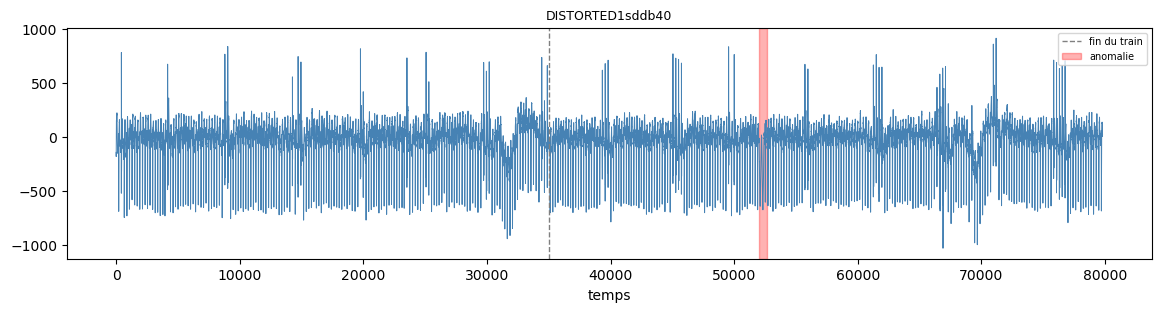

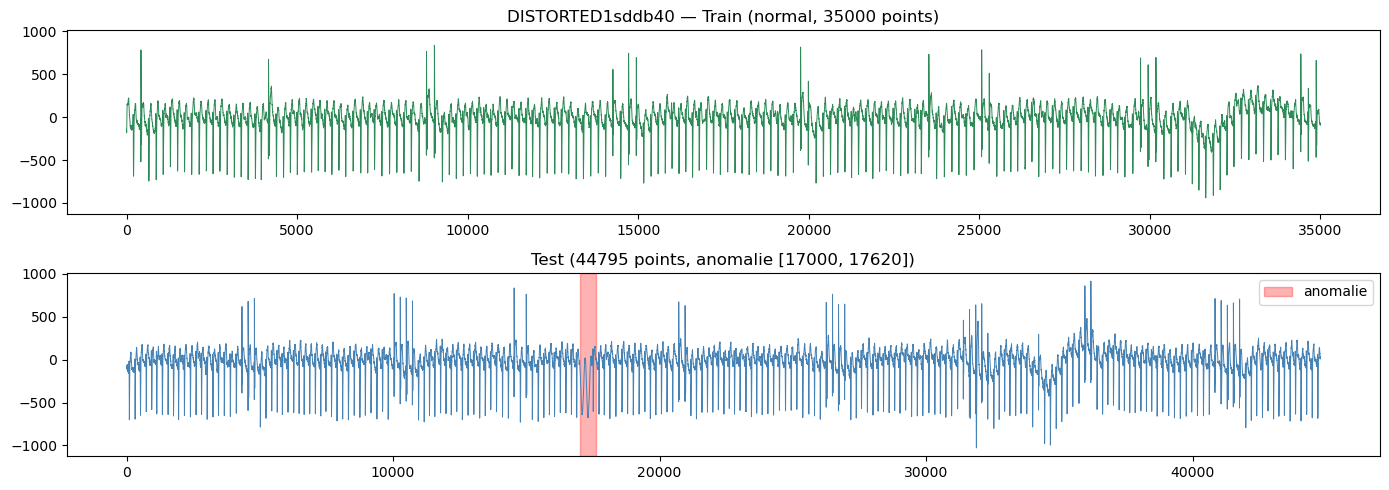

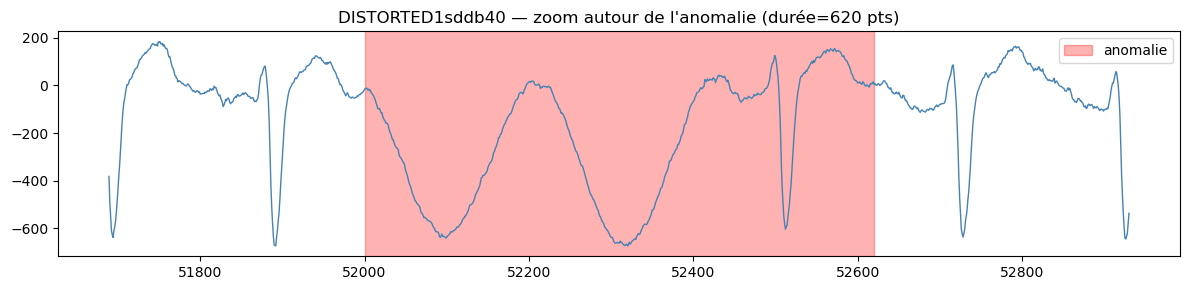

In [19]:
ROOT_DIR = "/home/2017025/ayouce01/FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic/data/ucr_anomaly/UCR_Anomaly_FullData"

dataset = load_ucr_anomaly_archive(ROOT_DIR)
print(f"{len(dataset)} séries chargées.\n")

# --- Statistiques globales ---
df = summarize_dataset(dataset)
print_dataset_summary(df)
df.to_csv("ucr_summary.csv", index=False)

# --- Visualisations ---
sample = dataset[0]

fig1 = plt.figure()
plot_series(sample)
fig2 = plot_train_test_split(sample)
fig3 = plot_zoom_on_anomaly(sample)

In [22]:
dataset[0]

{'series': array([-142.92883 , -164.93265 , -178.50742 , ...,   27.221281,
          34.907787,   21.102266], dtype=float32),
 'train': array([-142.92883 , -164.93265 , -178.50742 , ...,  -92.86408 ,
         -90.697105,  -95.68738 ], dtype=float32),
 'test': array([-89.59092 , -95.85533 , -96.993774, ...,  27.221281,  34.907787,
         21.102266], dtype=float32),
 'label': array([0, 0, 0, ..., 0, 0, 0]),
 'id': 1,
 'name': 'DISTORTED1sddb40',
 'train_end': 35000,
 'anomaly_start': 52000,
 'anomaly_end': 52620}

In [29]:
"""
Alternatives à MOMENT pour l'embedding de séries temporelles, en cas
de problème d'installation (dépendances lourdes, conflits, pas de GPU...).

Deux options, de la plus "deep learning" à la plus simple :

  A) TS2Vec  : auto-supervisé, PyTorch pur, nécessite d'ENTRAÎNER le modèle
               sur tes propres données (pas de poids pré-entraînés officiels
               à télécharger). Bon compromis qualité/simplicité.
               pip install torch numpy --break-system-packages
               (TS2Vec s'installe en clonant le repo, voir plus bas)

  B) MiniRocket : PAS de deep learning, convolutions aléatoires + pooling,
               tourne sur CPU en quelques secondes/minutes sur tout un
               dataset. Installation ultra simple via sktime.
               pip install sktime numpy --break-system-packages

Recommandation : si tu veux juste "que ça marche" sans galérer avec
l'installation -> pars sur MiniRocket (option B). Si tu veux un vrai
embedding appris et que tu es à l'aise avec PyTorch -> TS2Vec (option A).
"""

import os
import numpy as np
import pandas as pd


 
# ----------------------------------------------------------------------
# 2. Découpage en fenêtres + normalisation
# ----------------------------------------------------------------------
def make_windows(series: np.ndarray, window_size: int = 512, stride: int = 256):
    """
    Découpe une série en fenêtres glissantes.
    stride < window_size => fenêtres qui se chevauchent (recommandé pour
    la détection d'anomalies, afin de ne rater aucune zone).
    """
    n = len(series)
    windows, positions = [], []
 
    for start in range(0, max(1, n - window_size + 1), stride):
        windows.append(series[start:start + window_size])
        positions.append(start)
 
    # Si la série est plus courte que window_size, ou s'il reste un
    # reliquat en fin de série non couvert, on ajoute une fenêtre finale
    if not windows or positions[-1] + window_size < n:
        start = max(0, n - window_size)
        pad_len = window_size - (n - start)
        w = series[start:n]
        if pad_len > 0:
            w = np.pad(w, (0, pad_len), mode="edge")
        windows.append(w)
        positions.append(start)
 
    return np.stack(windows), np.array(positions)
 
 
def zscore_normalize(windows: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """
    Normalisation z-score par fenêtre (moyenne 0, écart-type 1).
    Indispensable : MOMENT (comme la plupart des foundation models de
    séries temporelles) attend des entrées normalisées, sinon les
    embeddings capturent surtout l'échelle plutôt que la forme.
    """
    mean = windows.mean(axis=1, keepdims=True)
    std = windows.std(axis=1, keepdims=True) + eps
    return (windows - mean) / std

# ========================================================================
# OPTION B (recommandée si tu veux éviter les galères d'install) : MiniRocket
# ========================================================================
def embed_dataset_minirocket_global(dataset: list, num_kernels: int = 10000):
    """
    Embedding GLOBAL (un vecteur par série) avec MiniRocket.
    Installation : pip install sktime --break-system-packages

    MiniRocket attend un format (n_instances, n_channels, n_timepoints).
    Comme les séries UCR ont des longueurs différentes, on les découpe
    d'abord en fenêtres de taille fixe (comme pour MOMENT), puis on
    fit/transform MiniRocket sur l'ensemble des fenêtres.
    """
    from sktime.transformations.panel.rocket import MiniRocket


    all_windows = []
    window_owner = []  # à quelle série appartient chaque fenêtre

    window_size, stride = 512, 256
    for sample in dataset:
        windows, _ = make_windows(sample["series"], window_size, stride)
        windows = zscore_normalize(windows)
        all_windows.append(windows)
        window_owner.extend([sample["id"]] * len(windows))

    X = np.concatenate(all_windows, axis=0)          # (n_windows_total, window_size)
    X = X[:, np.newaxis, :]                           # (n_windows_total, 1, window_size) format sktime

    print(f"Fit de MiniRocket sur {X.shape[0]} fenêtres...")
    rocket = MiniRocket(num_kernels=num_kernels, random_state=0)
    rocket.fit(X)
    features = rocket.transform(X).values             # (n_windows_total, n_features)

    # Moyenne des features par série pour obtenir UN embedding global
    df_features = pd.DataFrame(features)
    df_features["owner"] = window_owner
    global_embeddings = df_features.groupby("owner").mean()

    return global_embeddings, rocket  # rocket réutilisable pour transformer de nouvelles séries


def embed_series_minirocket_windows(rocket, series: np.ndarray,
                                     window_size: int = 512, stride: int = 256):
    """
    Embedding PAR FENÊTRE avec un MiniRocket déjà entraîné (mode détection
    d'anomalies). `rocket` doit venir de embed_dataset_minirocket_global.
    """

    windows, positions = make_windows(series, window_size, stride)
    windows = zscore_normalize(windows)
    X = windows[:, np.newaxis, :]
    features = rocket.transform(X).values
    return features, positions


In [30]:
ROOT_DIR = "/home/2017025/ayouce01/FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic/data/ucr_anomaly/UCR_Anomaly_FullData"

print("Chargement du dataset...")
dataset = load_ucr_anomaly_archive(ROOT_DIR)
print(f"{len(dataset)} séries chargées.\n")

# --------------------------------------------------------------
# Option B : MiniRocket (recommandé pour démarrer rapidement)
# --------------------------------------------------------------
print("=== MiniRocket ===")
global_embeddings, rocket = embed_dataset_minirocket_global(dataset)
print(f"Embeddings globaux shape : {global_embeddings.shape}")
global_embeddings.to_parquet("embeddings_minirocket_global.parquet")

# Embeddings par fenêtre pour la détection d'anomalies sur une série
sample = dataset[0]
win_features, positions = embed_series_minirocket_windows(rocket, sample["series"])
print(f"Série '{sample['name']}' : {win_features.shape[0]} fenêtres, "
        f"dim={win_features.shape[1]}")

Chargement du dataset...
250 séries chargées.

=== MiniRocket ===
Fit de MiniRocket sur 75465 fenêtres...
Embeddings globaux shape : (250, 9996)
Série 'DISTORTED1sddb40' : 311 fenêtres, dim=9996


In [31]:
global_embeddings.shape

(250, 9996)